# FD002 Classical Model Training: SVR and Random Forest

Local-only notebook for FD002 remaining useful life prediction with classical tabular models. It builds window-summary features, tunes SVR and Random Forest with `scikit-optimize` Bayesian search, and saves artifacts under `artifacts/fd002_classical_models`.

In [1]:
import json
import os
import random
import time
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import PredefinedSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from skopt import BayesSearchCV
from skopt.space import Integer, Real

warnings.filterwarnings("ignore", category=ConvergenceWarning)


In [2]:
SEED = 42
DATASET_NAME = "FD002"
RUL_CAP = 125
VAL_FRACTION = 0.2
WINDOW_LENGTH = 50
TRAIN_WINDOW_STRIDE = 5
REGIME_COUNT = 6

SENSOR_COLUMNS = [
    "s4",
    "s14",
    "s11",
    "s15",
    "s9",
    "s3",
    "s13",
    "s21",
    "s2",
    "s8",
    "s7",
    "s12",
]
OP_COLUMNS = ["op1", "op2", "op3"]
BASE_FEATURE_COLUMNS = SENSOR_COLUMNS + OP_COLUMNS

BAYES_SEARCH_ITERATIONS = 20
SVR_TUNING_SAMPLE_SIZE = 5000
RF_TUNING_SAMPLE_SIZE = 7000

EXPERIMENT_NAME = "fd002_classical_models"
SAVE_ARTIFACTS = True


In [3]:
RAW_COLUMNS = ["unit", "cycle", "op1", "op2", "op3"] + [f"s{i}" for i in range(1, 22)]
EXPECTED_RAW_FILES = ["train_FD002.txt", "test_FD002.txt", "RUL_FD002.txt"]


def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)


def unique_paths(paths: list[Path]) -> list[Path]:
    unique: list[Path] = []
    seen: set[str] = set()
    for raw_path in paths:
        path = Path(raw_path).expanduser()
        try:
            resolved = path.resolve()
        except FileNotFoundError:
            resolved = path.absolute()
        key = str(resolved)
        if key in seen:
            continue
        seen.add(key)
        unique.append(resolved)
    return unique


def looks_like_project_root(path: Path) -> bool:
    if not path.exists() or not path.is_dir():
        return False
    has_repo_layout = (path / "notebooks").is_dir() and (path / "data").is_dir()
    has_raw_files = all((path / "data" / "raw" / file_name).is_file() for file_name in EXPECTED_RAW_FILES)
    has_project_markers = (path / "AGENTS.md").is_file() or (path / "requirements.txt").is_file()
    return has_raw_files or (has_repo_layout and has_project_markers)


def resolve_project_root() -> Path:
    current_dir = Path.cwd().resolve()
    for candidate in unique_paths([current_dir, *current_dir.parents]):
        if looks_like_project_root(candidate):
            return candidate
    raise FileNotFoundError("Could not locate the local CMAPSS project root.")


def ensure_required_raw_files(project_root: Path) -> Path:
    raw_dir = project_root / "data" / "raw"
    missing = [file_name for file_name in EXPECTED_RAW_FILES if not (raw_dir / file_name).is_file()]
    if missing:
        raise FileNotFoundError(f"Missing required FD002 raw files in {raw_dir}: {', '.join(missing)}")
    return raw_dir


PROJECT_ROOT = resolve_project_root()
RAW_DIR = ensure_required_raw_files(PROJECT_ROOT)
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
ARTIFACT_DIR = PROJECT_ROOT / "artifacts" / EXPERIMENT_NAME

seed_everything(SEED)

print(f"Project root: {PROJECT_ROOT}")
print(f"Raw data directory: {RAW_DIR}")
print(f"Processed data directory: {PROCESSED_DIR}")
print(f"Artifact directory: {ARTIFACT_DIR}")


Project root: /Users/cihan/Desktop/CMAPSS
Raw data directory: /Users/cihan/Desktop/CMAPSS/data/raw
Processed data directory: /Users/cihan/Desktop/CMAPSS/data/processed
Artifact directory: /Users/cihan/Desktop/CMAPSS/artifacts/fd002_classical_models


In [4]:
def load_fd002_split(split: str) -> pd.DataFrame:
    frame = pd.read_csv(RAW_DIR / f"{split}_FD002.txt", sep=r"\s+", header=None).iloc[:, :26].copy()
    frame.columns = RAW_COLUMNS
    return frame


def load_fd002_test_rul() -> pd.DataFrame:
    rul = pd.read_csv(RAW_DIR / "RUL_FD002.txt", sep=r"\s+", header=None)
    rul.columns = ["true_rul"]
    rul["unit"] = np.arange(1, len(rul) + 1)
    rul["capped_true_rul"] = rul["true_rul"].clip(upper=RUL_CAP)
    return rul


def attach_regime_ids(frame: pd.DataFrame, split: str) -> pd.DataFrame:
    regime_path = PROCESSED_DIR / f"fd002_{split}_regimes.csv"
    if not regime_path.exists():
        raise FileNotFoundError(f"{regime_path} is missing")
    regimes = pd.read_csv(regime_path)
    merged = frame.merge(regimes, on=["unit", "cycle"], how="left")
    if merged["regime_id"].isna().any():
        raise ValueError(f"Missing regime_id values after merging {regime_path.name}")
    merged["regime_id"] = merged["regime_id"].astype(int)
    return merged


def prepare_fd002_frames() -> tuple[pd.DataFrame, pd.DataFrame]:
    train_df = attach_regime_ids(load_fd002_split("train"), "train")
    test_df = attach_regime_ids(load_fd002_split("test"), "test")

    max_cycle = train_df.groupby("unit")["cycle"].transform("max")
    train_df["raw_rul"] = max_cycle - train_df["cycle"]
    train_df["target_rul"] = train_df["raw_rul"].clip(upper=RUL_CAP)

    test_df = test_df.merge(load_fd002_test_rul(), on="unit", how="left")
    return train_df, test_df


def split_train_and_val_units(train_df: pd.DataFrame, val_fraction: float, seed: int) -> tuple[np.ndarray, np.ndarray]:
    units = train_df["unit"].drop_duplicates().to_numpy()
    rng = np.random.default_rng(seed)
    rng.shuffle(units)
    val_count = max(1, int(len(units) * val_fraction))
    val_units = np.sort(units[:val_count])
    train_units = np.sort(units[val_count:])
    return train_units, val_units


train_frame, test_frame = prepare_fd002_frames()
train_units, val_units = split_train_and_val_units(train_frame, VAL_FRACTION, SEED)

print(f"Train units: {len(train_units)} | Val units: {len(val_units)} | Test units: {test_frame['unit'].nunique()}")


Train units: 208 | Val units: 52 | Test units: 259


In [5]:
def summarize_window(window: pd.DataFrame, base_columns: list[str], regime_count: int) -> dict[str, float]:
    features: dict[str, float] = {}
    values = window[base_columns]
    first_values = values.iloc[0]
    last_values = values.iloc[-1]

    for column in base_columns:
        series = values[column]
        features[f"{column}_last"] = float(last_values[column])
        features[f"{column}_mean"] = float(series.mean())
        features[f"{column}_std"] = float(series.std(ddof=0))
        features[f"{column}_min"] = float(series.min())
        features[f"{column}_max"] = float(series.max())
        features[f"{column}_delta"] = float(last_values[column] - first_values[column])

    features["regime_id_last"] = float(window["regime_id"].iloc[-1])
    for regime_id in range(regime_count):
        features[f"regime_{regime_id}_fraction"] = float((window["regime_id"] == regime_id).mean())
    return features


def build_tabular_examples(
    frame: pd.DataFrame,
    units: np.ndarray | None,
    target_column: str,
    window_length: int,
    stride: int,
    base_columns: list[str],
    regime_count: int,
    last_window_only: bool = False,
) -> tuple[pd.DataFrame, np.ndarray, pd.DataFrame]:
    if units is not None:
        frame = frame[frame["unit"].isin(units)].copy()

    rows: list[dict[str, float]] = []
    targets: list[float] = []
    metadata: list[dict[str, float | int]] = []

    for unit, group in frame.groupby("unit", sort=True):
        group = group.sort_values("cycle").reset_index(drop=True)
        if last_window_only:
            end_positions = [len(group) - 1]
        elif len(group) < window_length:
            end_positions = [len(group) - 1]
        else:
            end_positions = list(range(window_length - 1, len(group), stride))

        for end_position in end_positions:
            start_position = max(0, end_position - window_length + 1)
            window = group.iloc[start_position : end_position + 1]
            rows.append(summarize_window(window, base_columns, regime_count))
            targets.append(float(group.loc[end_position, target_column]))
            metadata.append(
                {
                    "unit": int(unit),
                    "cycle": int(group.loc[end_position, "cycle"]),
                    "true_rul": float(group.get("true_rul", pd.Series([np.nan] * len(group))).iloc[end_position]),
                    "capped_true_rul": float(
                        group.get("capped_true_rul", pd.Series([np.nan] * len(group))).iloc[end_position]
                    ),
                }
            )

    features = pd.DataFrame(rows).sort_index(axis=1)
    metadata_frame = pd.DataFrame(metadata)
    return features, np.asarray(targets, dtype=np.float32), metadata_frame


X_train, y_train, train_metadata = build_tabular_examples(
    train_frame,
    train_units,
    target_column="target_rul",
    window_length=WINDOW_LENGTH,
    stride=TRAIN_WINDOW_STRIDE,
    base_columns=BASE_FEATURE_COLUMNS,
    regime_count=REGIME_COUNT,
)
X_val, y_val, val_metadata = build_tabular_examples(
    train_frame,
    val_units,
    target_column="target_rul",
    window_length=WINDOW_LENGTH,
    stride=TRAIN_WINDOW_STRIDE,
    base_columns=BASE_FEATURE_COLUMNS,
    regime_count=REGIME_COUNT,
)
X_test, y_test, test_metadata = build_tabular_examples(
    test_frame,
    None,
    target_column="capped_true_rul",
    window_length=WINDOW_LENGTH,
    stride=WINDOW_LENGTH,
    base_columns=BASE_FEATURE_COLUMNS,
    regime_count=REGIME_COUNT,
    last_window_only=True,
)

print(f"Feature count: {X_train.shape[1]}")
print(f"Train rows: {len(X_train)} | Val rows: {len(X_val)} | Test rows: {len(X_test)}")


Feature count: 97
Train rows: 6657 | Val rows: 1641 | Test rows: 259


In [6]:
def regression_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    predictions = np.clip(y_pred, 0.0, float(RUL_CAP))
    return {
        "mae": float(mean_absolute_error(y_true, predictions)),
        "rmse": float(np.sqrt(mean_squared_error(y_true, predictions))),
    }


def make_tuning_subset(X: pd.DataFrame, y: np.ndarray, max_size: int, seed: int) -> tuple[pd.DataFrame, np.ndarray]:
    if len(X) <= max_size:
        return X.reset_index(drop=True), y
    rng = np.random.default_rng(seed)
    indices = np.sort(rng.choice(len(X), size=max_size, replace=False))
    return X.iloc[indices].reset_index(drop=True), y[indices]


def make_predefined_search_data(
    X_tune: pd.DataFrame,
    y_tune: np.ndarray,
    X_validation: pd.DataFrame,
    y_validation: np.ndarray,
) -> tuple[pd.DataFrame, np.ndarray, PredefinedSplit]:
    X_search = pd.concat([X_tune.reset_index(drop=True), X_validation.reset_index(drop=True)], ignore_index=True)
    y_search = np.concatenate([y_tune, y_validation])
    fold = np.concatenate([
        np.full(len(X_tune), -1, dtype=int),
        np.zeros(len(X_validation), dtype=int),
    ])
    return X_search, y_search, PredefinedSplit(fold)


X_svr_tune, y_svr_tune = make_tuning_subset(X_train, y_train, SVR_TUNING_SAMPLE_SIZE, SEED)
X_rf_tune, y_rf_tune = make_tuning_subset(X_train, y_train, RF_TUNING_SAMPLE_SIZE, SEED + 1)
X_svr_search, y_svr_search, svr_cv = make_predefined_search_data(X_svr_tune, y_svr_tune, X_val, y_val)
X_rf_search, y_rf_search, rf_cv = make_predefined_search_data(X_rf_tune, y_rf_tune, X_val, y_val)

print(f"SVR Bayesian search rows: {len(X_svr_search)} ({len(X_svr_tune)} train-sample + {len(X_val)} val)")
print(f"RF Bayesian search rows: {len(X_rf_search)} ({len(X_rf_tune)} train-sample + {len(X_val)} val)")


SVR Bayesian search rows: 6641 (5000 train-sample + 1641 val)
RF Bayesian search rows: 8298 (6657 train-sample + 1641 val)


In [7]:
def make_svr_pipeline() -> Pipeline:
    return Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("model", SVR(kernel="rbf", cache_size=1000)),
        ]
    )


def make_rf_model() -> RandomForestRegressor:
    return RandomForestRegressor(
        random_state=SEED,
        n_jobs=-1,
        bootstrap=True,
    )


def clean_search_params(params: dict[str, object]) -> dict[str, float | int | str]:
    cleaned: dict[str, float | int | str] = {}
    for key, value in params.items():
        clean_key = key.replace("model__", "")
        if isinstance(value, np.integer):
            cleaned[clean_key] = int(value)
        elif isinstance(value, np.floating):
            cleaned[clean_key] = float(value)
        else:
            cleaned[clean_key] = value
    return cleaned


def cv_results_to_history(search: BayesSearchCV, model_name: str) -> pd.DataFrame:
    frame = pd.DataFrame(search.cv_results_)
    keep_columns = [column for column in frame.columns if column.startswith("param_")]
    keep_columns += ["mean_test_score", "rank_test_score", "mean_fit_time"]
    history = frame[keep_columns].copy()
    history.insert(0, "model", model_name)
    history.insert(1, "trial", np.arange(1, len(history) + 1))
    history["val_rmse"] = -history["mean_test_score"]
    return history.sort_values("trial").reset_index(drop=True)


svr_search_space = {
    "model__C": Real(1e-1, 1e2, prior="log-uniform"),
    "model__gamma": Real(1e-4, 1.0, prior="log-uniform"),
    "model__epsilon": Real(0.2, 8.0, prior="uniform"),
}
rf_search_space = {
    "n_estimators": Integer(120, 420),
    "max_depth": Integer(6, 24),
    "min_samples_leaf": Integer(1, 8),
    "max_features": Real(0.4, 1.0, prior="uniform"),
}

svr_search = BayesSearchCV(
    estimator=make_svr_pipeline(),
    search_spaces=svr_search_space,
    n_iter=BAYES_SEARCH_ITERATIONS,
    scoring="neg_root_mean_squared_error",
    cv=svr_cv,
    random_state=SEED,
    n_jobs=1,
    refit=False,
    verbose=0,
)
rf_search = BayesSearchCV(
    estimator=make_rf_model(),
    search_spaces=rf_search_space,
    n_iter=BAYES_SEARCH_ITERATIONS,
    scoring="neg_root_mean_squared_error",
    cv=rf_cv,
    random_state=SEED + 10,
    n_jobs=1,
    refit=False,
    verbose=0,
)

start = time.time()
svr_search.fit(X_svr_search, y_svr_search)
svr_search_seconds = time.time() - start

start = time.time()
rf_search.fit(X_rf_search, y_rf_search)
rf_search_seconds = time.time() - start

svr_best_params = clean_search_params(svr_search.best_params_)
rf_best_params = clean_search_params(rf_search.best_params_)
optimization_history = pd.concat(
    [cv_results_to_history(svr_search, "svr"), cv_results_to_history(rf_search, "random_forest")],
    ignore_index=True,
)

print(f"SVR BayesSearchCV best validation RMSE: {-svr_search.best_score_:.4f}")
print("SVR best params:", svr_best_params)
print(f"Random Forest BayesSearchCV best validation RMSE: {-rf_search.best_score_:.4f}")
print("Random Forest best params:", rf_best_params)
print(f"SVR search seconds: {svr_search_seconds:.1f}")
print(f"RF search seconds: {rf_search_seconds:.1f}")


SVR BayesSearchCV best validation RMSE: 22.4703
SVR best params: {'C': 100.0, 'epsilon': 8.0, 'gamma': 0.0016273360571811945}
Random Forest BayesSearchCV best validation RMSE: 22.0589
Random Forest best params: {'max_depth': 24, 'max_features': 0.4, 'min_samples_leaf': 1, 'n_estimators': 420}
SVR search seconds: 14.8
RF search seconds: 51.8


In [8]:
svr_model = make_svr_pipeline().set_params(**{f"model__{key}": value for key, value in svr_best_params.items()})
rf_model = make_rf_model().set_params(**rf_best_params)

fit_start = time.time()
svr_model.fit(X_train, y_train)
svr_fit_seconds = time.time() - fit_start

fit_start = time.time()
rf_model.fit(X_train, y_train)
rf_fit_seconds = time.time() - fit_start

svr_test_predictions = np.clip(svr_model.predict(X_test), 0.0, float(RUL_CAP))
rf_test_predictions = np.clip(rf_model.predict(X_test), 0.0, float(RUL_CAP))

metrics = {
    "svr": regression_metrics(y_test, svr_test_predictions),
    "random_forest": regression_metrics(y_test, rf_test_predictions),
}

print("SVR test metrics (clipped/capped target):", metrics["svr"])
print("Random Forest test metrics (clipped/capped target):", metrics["random_forest"])
print(f"SVR final fit seconds: {svr_fit_seconds:.1f}")
print(f"RF final fit seconds: {rf_fit_seconds:.1f}")


SVR test metrics (clipped/capped target): {'mae': 16.258491778951708, 'rmse': 20.9150653176583}
Random Forest test metrics (clipped/capped target): {'mae': 16.523583852428448, 'rmse': 20.783534571350625}
SVR final fit seconds: 0.6
RF final fit seconds: 3.2


In [9]:
test_results = test_metadata.copy()
test_results["capped_true_rul"] = y_test
test_results["svr_prediction_capped"] = svr_test_predictions
test_results["rf_prediction_capped"] = rf_test_predictions
test_results["svr_absolute_error_capped"] = np.abs(test_results["capped_true_rul"] - test_results["svr_prediction_capped"])
test_results["rf_absolute_error_capped"] = np.abs(test_results["capped_true_rul"] - test_results["rf_prediction_capped"])

test_results.head()


,unit,cycle,true_rul,capped_true_rul,svr_prediction_capped,rf_prediction_capped,svr_absolute_error_capped,rf_absolute_error_capped
0,1,258,18.0,18.0,7.291493,14.416667,10.708507,3.583333
1,2,55,79.0,79.0,80.062968,98.029218,1.062968,19.029218
2,3,165,106.0,106.0,85.391353,96.764645,20.608647,9.235355
3,4,86,110.0,110.0,72.401093,70.806101,37.598907,39.193899
4,5,148,15.0,15.0,15.647345,25.228571,0.647345,10.228571


In [10]:
if SAVE_ARTIFACTS:
    ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

    config = {
        "seed": SEED,
        "dataset_name": DATASET_NAME,
        "rul_cap": RUL_CAP,
        "val_fraction": VAL_FRACTION,
        "window_length": WINDOW_LENGTH,
        "train_window_stride": TRAIN_WINDOW_STRIDE,
        "sensor_columns": SENSOR_COLUMNS,
        "op_columns": OP_COLUMNS,
        "base_feature_columns": BASE_FEATURE_COLUMNS,
        "feature_count": int(X_train.shape[1]),
        "train_rows": int(len(X_train)),
        "val_rows": int(len(X_val)),
        "test_rows": int(len(X_test)),
        "optimization_method": "skopt.BayesSearchCV",
        "bayes_search_iterations": BAYES_SEARCH_ITERATIONS,
        "svr_tuning_sample_size": int(len(X_svr_tune)),
        "rf_tuning_sample_size": int(len(X_rf_tune)),
        "svr_best_validation_rmse": float(-svr_search.best_score_),
        "rf_best_validation_rmse": float(-rf_search.best_score_),
        "svr_best_params": svr_best_params,
        "rf_best_params": rf_best_params,
        "svr_search_seconds": float(svr_search_seconds),
        "rf_search_seconds": float(rf_search_seconds),
        "svr_fit_seconds": float(svr_fit_seconds),
        "rf_fit_seconds": float(rf_fit_seconds),
    }

    test_results.to_csv(ARTIFACT_DIR / "test_predictions.csv", index=False)
    optimization_history.to_csv(ARTIFACT_DIR / "optimization_history.csv", index=False)
    pd.Series(X_train.columns, name="feature").to_csv(ARTIFACT_DIR / "feature_columns.csv", index=False)

    rf_importance = pd.DataFrame(
        {
            "feature": X_train.columns,
            "importance": rf_model.feature_importances_,
        }
    ).sort_values("importance", ascending=False)
    rf_importance.to_csv(ARTIFACT_DIR / "random_forest_feature_importance.csv", index=False)

    (ARTIFACT_DIR / "config.json").write_text(json.dumps(config, indent=2))
    (ARTIFACT_DIR / "metrics.json").write_text(json.dumps(metrics, indent=2))
    joblib.dump(svr_model, ARTIFACT_DIR / "svr_model.joblib")
    joblib.dump(rf_model, ARTIFACT_DIR / "random_forest_model.joblib")

print(f"Saved artifacts to {ARTIFACT_DIR}")


Saved artifacts to /Users/cihan/Desktop/CMAPSS/artifacts/fd002_classical_models


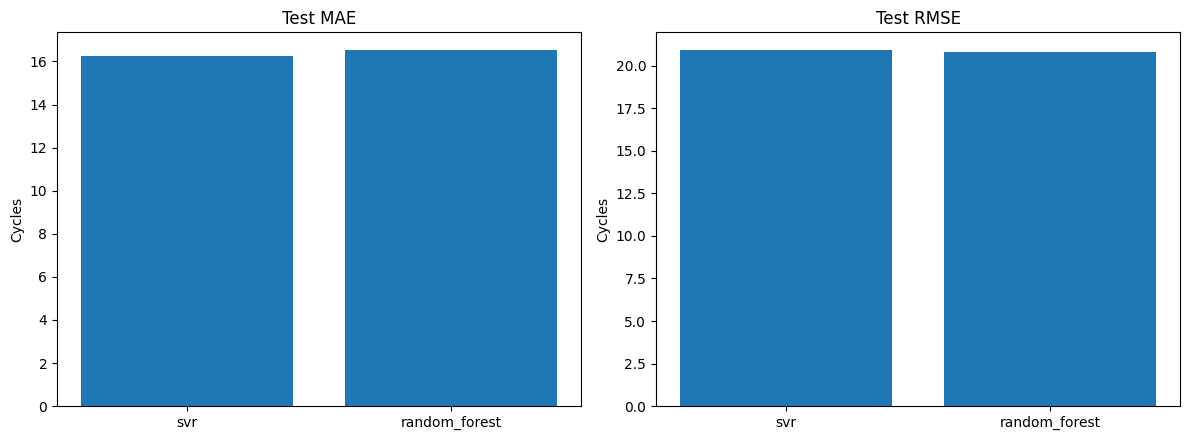

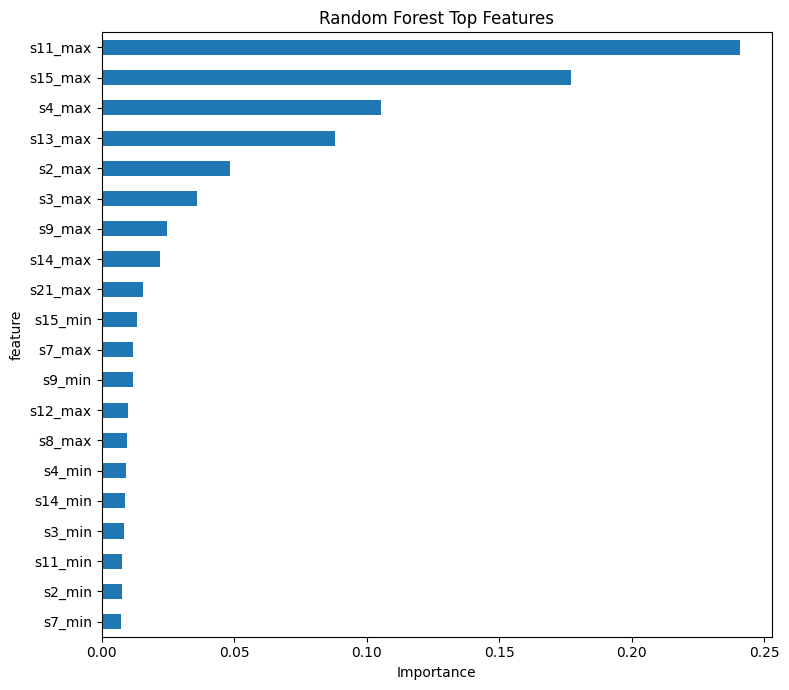

In [11]:
metrics_frame = pd.DataFrame(metrics).T.reset_index(names="model")
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(metrics_frame["model"], metrics_frame["mae"])
axes[0].set_title("Test MAE")
axes[0].set_ylabel("Cycles")

axes[1].bar(metrics_frame["model"], metrics_frame["rmse"])
axes[1].set_title("Test RMSE")
axes[1].set_ylabel("Cycles")

fig.tight_layout()
plt.show()

rf_importance.head(20).sort_values("importance").plot.barh(x="feature", y="importance", figsize=(8, 7), legend=False)
plt.title("Random Forest Top Features")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()
